# Detecção de Anomalias em Licitações Públicas do Paraná (2020–2025)
## Pipeline Completo: Pré-processamento → Enriquecimento → ML Não-Supervisionado

---

Este notebook é **autocontido**: executa todas as etapas desde o carregamento dos CSVs até a exportação dos resultados, seguindo o processo KDD (Fayyad et al., 1996).

### Estrutura

| Seção | Etapa KDD | Conteúdo |
|---|---|---|
| 1 | — | Importações e configurações globais |
| 2 | Seleção | Carregamento dos CSVs (2020–2025) |
| 3 | Pré-processamento | Limpeza, datas, valores monetários |
| 4 | Transformação | Features derivadas (sobrepreço, lead time) |
| 5 | Enriquecimento | Cruzamento com IDHM e população municipal |
| 6 | Transformação | Engenharia de features para ML (14 variáveis) |
| 7 | Transformação | Normalização com RobustScaler |
| 8 | Mineração | Isolation Forest |
| 9 | Mineração | Local Outlier Factor (LOF) + Concordância |
| 10 | Mineração | Score ensemble e classificação final |
| 10b | Avaliação | Validação indireta — Lei 14.133/2021 |
| 11 | Interpretação | Visualizações e top anomalias |
| 12 | — | Exportação dos resultados (CSV) |
| 13 | — | Sumário e limitações |


---
## 1 — Importações e Configurações Globais

In [152]:
import warnings
warnings.filterwarnings('ignore')

import re
import unicodedata
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display, FileLink

from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# SHAP: interpretabilidade por instância (opcional — pip install shap)
try:
    import shap
    SHAP_DISPONIVEL = True
    print('SHAP disponível')
except ImportError:
    SHAP_DISPONIVEL = False
    print('SHAP não instalado — análise por z-score será usada como alternativa')

# ---------------------------------------------------------------------------
# CONFIGURAÇÕES GLOBAIS
# ---------------------------------------------------------------------------
pd.options.display.max_columns  = 50
pd.options.display.max_colwidth = 120
pd.options.display.float_format  = lambda x: f'{x:,.2f}'

EXPORTS_DIR  = Path('exports')
EXPORTS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

# Valor mínimo para que valor_estimado seja considerado financeiramente válido.
# Registros com valor_estimado abaixo deste patamar (ex: R$100, R$1) são erros
# de cadastro — quando cruzados com valor_homologado real, geram sobrepreços
# fictícios de milhões de porcento que distorcem completamente os resultados.
# Justificativa: o menor limite de dispensa da Lei 14.133/2021 (Art. 75)
# é R$50.000 — qualquer licitação real tem estimativa na casa dos milhares.
VALOR_ESTIMADO_MIN = 10_000  # R$ 10.000

# Limite superior calculado dinamicamente no cod-03 (P99.9 do valor_estimado).
# Registros com valor_estimado acima deste patamar são erros de cadastro.
VALOR_ESTIMADO_MAX = None

print('Configuração concluída.')


SHAP disponível
Configuração concluída.


---
## 2 — Seleção dos Dados

Carregamos os seis arquivos CSV de licitações públicas do Estado do Paraná
(um por ano, 2020–2025) e os concatenamos em um único DataFrame.

Todos os campos são lidos como texto (`dtype=str`) para evitar conversões
automáticas incorretas — a tipagem correta é feita na próxima seção.


In [153]:
csv_paths = [
    Path('./data/TB_LICITACOES-2025.csv'),
    Path('./data/TB_LICITACOES-2024.csv'),
    Path('./data/TB_LICITACOES-2023.csv'),
    Path('./data/TB_LICITACOES-2022.csv'),
    Path('./data/TB_LICITACOES-2021.csv'),
    Path('./data/TB_LICITACOES-2020.csv'),
]

frames = []
for path_csv in csv_paths:
    if not path_csv.exists():
        print(f'  AVISO: {path_csv.name} não encontrado — ignorado')
        continue
    frame = (
        pd.read_csv(path_csv, sep=';', dtype=str)
            .rename(columns=str.lower)
            .assign(arquivo=path_csv.name)
    )
    frames.append(frame)
    print(f'  {path_csv.name}: {len(frame):,} registros')

raw_df = pd.concat(frames, ignore_index=True)

print(f'\nTotal carregado: {len(raw_df):,} registros')
print(f'Colunas brutas ({raw_df.shape[1]}): {raw_df.columns.tolist()}')


  TB_LICITACOES-2025.csv: 1,732 registros
  TB_LICITACOES-2024.csv: 2,645 registros
  TB_LICITACOES-2023.csv: 2,725 registros
  TB_LICITACOES-2022.csv: 2,708 registros
  TB_LICITACOES-2021.csv: 2,028 registros
  TB_LICITACOES-2020.csv: 1,698 registros

Total carregado: 13,536 registros
Colunas brutas (19): ['numprocesso', 'ano', 'modalidade', 'situacao', 'objeto', 'orgao', 'registrodepreco', 'vigenciaata', 'revogacaoata', 'criteriojulgamento', 'valor_estimado', 'valor_ou_desconto_homologado', 'dataabertura', 'datahomologacao', 'localdisputa', 'idlicitacoes', 'protocolo', 'tempoprazocontrato', 'arquivo']


---
## 3 — Pré-processamento

Transformamos os dados brutos em um formato utilizável:

1. **Remoção de colunas irrelevantes** para a análise de anomalias
2. **Conversão de datas** (`dataabertura`, `datahomologacao`) para `datetime`
3. **Conversão de valores monetários** do formato brasileiro para `float`
4. **Normalização do texto** (`objeto`) para facilitar classificação por palavras-chave

Ao final imprimimos o perfil completo do dataset resultante — colunas, tipos
e percentual de preenchimento de cada campo.


In [154]:
def para_datetime(series, fmt='%Y-%m-%d'):
    """Converte Series de strings para datetime; erros viram NaT."""
    return pd.to_datetime(series, format=fmt, errors='coerce')


def converter_valor_br(series):
    """
    Converte string monetária brasileira para float.
    Exemplo: '1.234.567,89'  →  1234567.89
    """
    return pd.to_numeric(
        series
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False),
        errors='coerce'
    )


clean_df = raw_df.copy()

# ---------------------------------------------------------------------------
# 3.1 — Remoção de colunas
# registrodepreco    → binário sem valor analítico direto
# vigenciaata        → aplicável só a contratos, fora do escopo
# revogacaoata       → idem
# localdisputa       → não influencia detecção de anomalias financeiras
# idlicitacoes       → identificador interno
# protocolo          → idem
# tempoprazocontrato → texto livre não estruturado
# ---------------------------------------------------------------------------
colunas_remover = [
    'registrodepreco', 'vigenciaata', 'revogacaoata',
    'localdisputa', 'idlicitacoes', 'protocolo', 'tempoprazocontrato'
]
clean_df = clean_df.drop(columns=colunas_remover, errors='ignore')

# ---------------------------------------------------------------------------
# 3.2 — Conversão de datas
# ---------------------------------------------------------------------------
clean_df['dataabertura']    = para_datetime(clean_df['dataabertura'])
clean_df['datahomologacao'] = para_datetime(clean_df['datahomologacao'])

# ---------------------------------------------------------------------------
# 3.3 — Conversão de valores monetários
# ---------------------------------------------------------------------------
for col in ['valor_estimado', 'valor_ou_desconto_homologado']:
    if col in clean_df.columns:
        clean_df[col] = converter_valor_br(clean_df[col])

# ---------------------------------------------------------------------------
# 3.4 — Normalização do texto do objeto
# ---------------------------------------------------------------------------
clean_df['objeto_normalizado'] = (
    clean_df['objeto']
    .str.lower()
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

# ---------------------------------------------------------------------------
# PERFIL DO DATASET APÓS PRÉ-PROCESSAMENTO
# ---------------------------------------------------------------------------
print('=' * 65)
print('DATASET APÓS PRÉ-PROCESSAMENTO')
print('=' * 65)
print(f'  Registros : {len(clean_df):,}')
print(f'  Colunas   : {clean_df.shape[1]}')
print()
print(f'  {"Coluna":<42} {"Tipo":<14} Preenchimento')
print(f'  {"-"*42} {"-"*14} {"-"*14}')
for col in clean_df.columns:
    n_nulos = clean_df[col].isna().sum()
    pct_ok  = (1 - n_nulos / len(clean_df)) * 100
    print(f'  {col:<42} {str(clean_df[col].dtype):<14} {pct_ok:>6.1f}%')

print()
display(clean_df.head(3))

# ---------------------------------------------------------------------------
# VALOR_ESTIMADO_MAX: P99.9 calculado de forma data-driven
# Valores acima deste limiar são tipicamente erros de cadastro que
# distorceriam a feature valor_estimado_log1p no modelo.
# ---------------------------------------------------------------------------
VALOR_ESTIMADO_MAX = clean_df['valor_estimado'].quantile(0.999)
print(f'VALOR_ESTIMADO_MAX (P99.9): R$ {VALOR_ESTIMADO_MAX:,.0f}')


DATASET APÓS PRÉ-PROCESSAMENTO
  Registros : 13,536
  Colunas   : 13

  Coluna                                     Tipo           Preenchimento
  ------------------------------------------ -------------- --------------
  numprocesso                                object          100.0%
  ano                                        object          100.0%
  modalidade                                 object          100.0%
  situacao                                   object          100.0%
  objeto                                     object          100.0%
  orgao                                      object          100.0%
  criteriojulgamento                         object          100.0%
  valor_estimado                             float64          97.7%
  valor_ou_desconto_homologado               float64          63.8%
  dataabertura                               datetime64[ns]   99.9%
  datahomologacao                            datetime64[ns]   79.5%
  arquivo                        

,numprocesso,ano,modalidade,situacao,objeto,orgao,criteriojulgamento,valor_estimado,valor_ou_desconto_homologado,dataabertura,datahomologacao,arquivo,objeto_normalizado
0,1,2025,Audiência Pública,Fase Certame,Audiência Pública visa consultar os eventuais interessados no Credenciamento de Entidades Médicas e Psicológicas de ...,DETRAN-Departamento de Trânsito do Estado do Paraná,-,0.00,NaN,2025-02-19,NaT,TB_LICITACOES-2025.csv,audiência pública visa consultar os eventuais interessados no credenciamento de entidades médicas e psicológicas de ...
1,2,2025,Audiência Pública,Adjudicado,AUDIÊNCIA PÚBLICA DO PROGRAMA GANHANDO O MUNDO.,SEED-Secretaria de Estado da Educação,Menor Preço,0.00,NaN,2025-05-22,NaT,TB_LICITACOES-2025.csv,audiência pública do programa ganhando o mundo.
2,3,2025,Audiência Pública,Fase Certame,Audiência Pública que visa obter contribuições para compor o Estudo Técnico Preliminar e Termo de Referência para po...,SEAP-Secretaria de Estado da Administração e da Previdência,Menor Preço,0.00,NaN,2025-06-04,NaT,TB_LICITACOES-2025.csv,audiência pública que visa obter contribuições para compor o estudo técnico preliminar e termo de referência para po...


VALOR_ESTIMADO_MAX (P99.9): R$ 68,925,652,200


---
## 4 — Transformação: Features Derivadas

Criamos variáveis que não existem diretamente nos dados mas capturam padrões
relevantes para detecção de anomalias:

| Variável | Como é calculada | O que captura |
|---|---|---|
| `proporcao_homologado_estimado` | homologado / estimado | > 1 = sobrepreço; < 1 = desconto |
| `flag_sobrepreco` | proporção > 1 | Flag binária de sobrepreço |
| `lead_time_dias` | (datahomologacao − dataabertura).days | Duração do processo |
| `ano_abertura` | dataabertura.year | Ano do certame |
| `volume_licitacoes_orgao_ano` | count por (orgao, ano) | Volume anual do órgão |


In [155]:
v_est = clean_df['valor_estimado'].fillna(0)
v_hom = clean_df['valor_ou_desconto_homologado'].fillna(0)

# ---------------------------------------------------------------------------
# Condição de validade financeira
# Só calculamos sobrepreço quando:
#   (a) valor_estimado >= VALOR_ESTIMADO_MIN — elimina placeholders tipo R$100
#   (b) valor_homologado > 0 — processo efetivamente homologado com valor
# ---------------------------------------------------------------------------
cond_financeiro = (v_est >= VALOR_ESTIMADO_MIN) & (v_hom > 0)

n_invalidos = ((v_est > 0) & (v_est < VALOR_ESTIMADO_MIN)).sum()
print(f'Registros com valor_estimado inválido (< R${VALOR_ESTIMADO_MIN:,.0f}): '
      f'{n_invalidos:,} — excluídos da análise financeira')

# Proporção homologado/estimado — cap em 10x para não distorcer o scaler
clean_df['proporcao_homologado_estimado'] = np.where(
    cond_financeiro,
    np.clip(v_hom / v_est, 0, 10),
    np.nan
)
clean_df['flag_sobrepreco'] = clean_df['proporcao_homologado_estimado'] > 1

# ---------------------------------------------------------------------------
# Lead time — prazos negativos (erro de data) são zerados
# ---------------------------------------------------------------------------
clean_df['lead_time_dias'] = (
    (clean_df['datahomologacao'] - clean_df['dataabertura'])
    .dt.days
    .clip(lower=0)
)

# ---------------------------------------------------------------------------
# Ano e volume por órgão/ano
# Volume alto pode indicar fracionamento de contratos
# (Art. 137 § 2º, Lei 14.133/2021)
# ---------------------------------------------------------------------------
clean_df['ano_abertura'] = clean_df['dataabertura'].dt.year.fillna(0).astype(int)

clean_df['volume_licitacoes_orgao_ano'] = (
    clean_df.groupby(['orgao', 'ano_abertura'])['numprocesso']
    .transform('count')
)

print(f'Sobrepreços detectados (com dados válidos): {clean_df["flag_sobrepreco"].sum():,}')
print(f'Lead time médio dos processos finalizados:  {clean_df["lead_time_dias"].mean():.0f} dias')


Registros com valor_estimado inválido (< R$10,000): 40 — excluídos da análise financeira
Sobrepreços detectados (com dados válidos): 98
Lead time médio dos processos finalizados:  45 dias


---
## 5 — Enriquecimento com IDHM e População (IDHM-PR.csv)

### Por que cruzar com dados populacionais e de desenvolvimento?

Com os dados de licitação isolados, não temos contexto para avaliar se um gasto
é alto ou baixo. Por exemplo:

> Uma obra de R$ 500.000 pode ser normal para Curitiba (1,9 milhão de habitantes)
> e extremamente anômala para um município de 3.000 habitantes.

Ao cruzar com **população** e **IDHM** de cada município, conseguimos:
- Calcular o **gasto per capita** por tipo de licitação
- Comparar cada município com **peers** de tamanho e desenvolvimento similares
- Detectar desvios que fazem sentido socioeconômico, e não apenas estatístico

### Dataset IDHM-PR.csv
Contém os 399 municípios do Paraná com:
- **POPULAÇÃO**: estimativa populacional
- **IDHM 2010**: Índice de Desenvolvimento Humano Municipal (0–1, maior = melhor)

### Estratégia de extração do município
O campo `orgao` contém o nome do órgão licitante, que frequentemente inclui
o município. Busco os 399 nomes de cidades do IDHM-PR diretamente no campo
`orgao` (normalizado sem acentos) para fazer o match.

### Classificação do objeto por categoria
Cada licitação é classificada por tipo (obras, saúde, educação, etc.) usando
palavras-chave no campo `objeto`. Isso permite comparar gastos per capita
**dentro da mesma categoria** — obras não podem ser comparadas a medicamentos.


In [156]:
def normalizar_texto(texto):
    """Remove acentos, coloca em minúsculas e colapsa espaços."""
    if pd.isna(texto):
        return ''
    texto = str(texto).lower().strip()
    texto = unicodedata.normalize('NFD', texto)
    texto = ''.join(c for c in texto if unicodedata.category(c) != 'Mn')
    return re.sub(r'\s+', ' ', texto)


# ---------------------------------------------------------------------------
# Carrega o IDHM-PR.csv
# Colunas: (index), CIDADE, POPULAÇÃO, IDHM 2010
# POPULAÇÃO usa ponto como milhar: '125.861' → 125861
# IDHM usa vírgula como decimal:   '0,699'   → 0.699
# ---------------------------------------------------------------------------
idhm_raw = pd.read_csv('./data/IDHM-PR.csv', index_col=0)
idhm_raw.columns = idhm_raw.columns.str.strip()

idhm_df = pd.DataFrame()
idhm_df['cidade_original'] = idhm_raw['CIDADE'].str.strip()
idhm_df['populacao'] = (
    idhm_raw['POPULAÇÃO']
    .astype(str)
    .str.replace('.', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)
idhm_df['idhm'] = (
    idhm_raw['IDHM 2010']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)
idhm_df['cidade_norm'] = idhm_df['cidade_original'].apply(normalizar_texto)

print(f'IDHM-PR carregado: {len(idhm_df)} municípios')
print(f'  IDHM:      {idhm_df["idhm"].min():.3f} – {idhm_df["idhm"].max():.3f}')
print()
display(idhm_df.head(5))


IDHM-PR carregado: 399 municípios
  IDHM:      0.546 – 0.823



,cidade_original,populacao,idhm,cidade_norm
PR,Abatiá,7233,0.69,abatia
PR,Adrianópolis,6319,0.67,adrianopolis
PR,Agudos do Sul,10770,0.66,agudos do sul
PR,Almirante Tamandaré,125861,0.70,almirante tamandare
PR,Altamira do Paraná,3496,0.67,altamira do parana


In [157]:
# ---------------------------------------------------------------------------
# Match de município no campo 'orgao'
# Ordenamos as cidades do maior para o menor nome para garantir que nomes
# mais longos (mais específicos) sejam testados primeiro e evitem matches
# parciais incorretos (ex: 'Irati' dentro de 'Ariranha do Ivaí').
# ---------------------------------------------------------------------------
cidades_sorted = idhm_df.sort_values('cidade_norm', key=lambda s: -s.str.len())
lookup_cidade  = dict(zip(cidades_sorted['cidade_norm'], cidades_sorted['cidade_original']))


def extrair_cidade(orgao_norm):
    """Retorna o nome original da cidade encontrado no orgao_norm, ou None."""
    for cidade_norm, cidade_orig in lookup_cidade.items():
        if re.search(r'\b' + re.escape(cidade_norm) + r'\b', orgao_norm):
            return cidade_orig
    return None


clean_df['orgao_norm']         = clean_df['orgao'].apply(normalizar_texto)
clean_df['municipio_extraido'] = clean_df['orgao_norm'].apply(extrair_cidade)

n_com_cidade = clean_df['municipio_extraido'].notna().sum()
print(f'Município identificado: {n_com_cidade:,} de {len(clean_df):,} registros '
      f'({n_com_cidade/len(clean_df)*100:.1f}%)')
print()
print('Exemplos de matches:')
print(
    clean_df.loc[clean_df['municipio_extraido'].notna(), ['orgao', 'municipio_extraido']]
    .drop_duplicates('municipio_extraido')
    .head(10)
    .to_string(index=False)
)


Município identificado: 2,457 de 13,536 registros (18.2%)

Exemplos de matches:
                                                                                    orgao      municipio_extraido
                                                     UEM-Universidade Estadual de Maringá                 Maringá
                 UNIOESTE TOLEDO-Universidade Estadual do Oeste do Paraná - Campus Toledo                  Toledo
             UNIOESTE FOZ-Universidade Estadual do Oeste do Paraná - Campus Foz do Iguaçu           Foz do Iguaçu
                                                    UEL-Universidade Estadual de Londrina                Londrina
UNIOESTE MCROND-Universidade Estadual do Oeste do Paraná - Campus Marechal Cândido Rondon Marechal Cândido Rondon
                                               UEPG-Universidade Estadual de Ponta Grossa            Ponta Grossa
                                    APPA-Administração dos Portos de Paranaguá e Antonina               Paranaguá
        

In [158]:
# ---------------------------------------------------------------------------
# Merge: adiciona população e IDHM ao dataset
# Órgãos estaduais (sem município identificado) ficam com NaN — o modelo
# trata isso como ausência de dado contextual.
# ---------------------------------------------------------------------------
clean_df = clean_df.merge(
    idhm_df[['cidade_original', 'populacao', 'idhm']],
    left_on='municipio_extraido',
    right_on='cidade_original',
    how='left'
).drop(columns='cidade_original')

print(f'Registros com população: {clean_df["populacao"].notna().sum():,} '
      f'({clean_df["populacao"].notna().mean()*100:.1f}%)')
print(f'Registros sem município (estaduais): {clean_df["municipio_extraido"].isna().sum():,}')


Registros com população: 2,457 (18.2%)
Registros sem município (estaduais): 11,079


In [159]:
# ---------------------------------------------------------------------------
# Classificação do objeto por categoria
# Cada licitação recebe uma categoria com base em palavras-chave no objeto.
# Isso permite comparar gastos per capita DENTRO da mesma categoria:
# não faz sentido comparar gasto de obras com gasto de medicamentos.
#
# A ordem das categorias importa: a primeira palavra-chave que bater define
# a categoria. Categorias mais específicas (saúde, obras) vêm antes das
# mais genéricas (serviços), evitando que "manutenção de equipamentos médicos"
# caia em "serviços" em vez de "saúde".
# ---------------------------------------------------------------------------
CATEGORIAS_OBJETO = {
    # ─── Obras e infraestrutura ─────────────────────────────────────────────
    'obras': [
        'obra', 'construcao', 'reforma', 'pavimentacao', 'calcamento',
        'asfalto', 'recapeamento', 'saneamento', 'drenagem', 'esgoto',
        'terraplanagem', 'pontes', 'viaduto', 'galeria', 'calcada',
        'iluminacao publica', 'rede eletrica', 'calçamento', 'calçada',
        'urbanizacao', 'infraestrutura', 'revitalizacao',
    ],

    # ─── Saúde ──────────────────────────────────────────────────────────────
    'saude': [
        'saude', 'medicamento', 'farmacia', 'hospital', 'ambulancia',
        'equipamento medico', 'ubs', 'unidade basica', 'vacina',
        'enfermagem', 'cirurgico', 'odontologico', 'laboratorio',
        'radiologia', 'fisioterapia', 'hemocentro', 'pronto socorro',
        'upa', 'insumo hospitalar', 'material hospitalar', 'leito',
        'atendimento medico', 'diagnostico', 'ortopedico', 'oftalmologico',
        'produtos farmaceuticos', 'nutrição enteral', 'nutricao parenteral',
    ],

    # ─── Educação ───────────────────────────────────────────────────────────
    'educacao': [
        'educacao', 'escola', 'creche', 'material didatico', 'merenda escolar',
        'livro', 'biblioteca', 'ensino', 'pedagogico', 'universitario',
        'quadra esportiva', 'laboratorio de informatica', 'material escolar',
        'formacao de professores', 'capacitacao', 'treinamento', 'curso',
        'aprendizagem', 'educacional', 'colegio', 'aluno', 'bolsa',
    ],

    # ─── Veículos e mobilidade ──────────────────────────────────────────────
    'veiculos': [
        'veiculo', 'caminhao', 'onibus', 'automovel', 'motocicleta', 'moto',
        'trator', 'pneu', 'manutencao de veiculo', 'manutencao veicular',
        'revisao veicular', 'revisao de veiculo', 'van', 'micro-onibus',
        'retroescavadeira', 'pa carregadeira', 'motoniveladora', 'ambulancia',
        'transporte escolar', 'transporte de passageiros', 'fretamento',
    ],

    # ─── Combustível (separado de veículos para precisão) ───────────────────
    'combustivel': [
        'combustivel', 'gasolina', 'diesel', 'etanol', 'oleo diesel',
        'abastecimento de veiculo', 'lubrificante', 'oleo lubrificante',
    ],

    # ─── Alimentação ────────────────────────────────────────────────────────
    'alimentacao': [
        'alimentacao', 'alimento', 'generos alimenticios', 'refeicao',
        'merenda', 'abastecimento alimentar', 'cestas basicas',
        'produtos alimenticios', 'hortifruti', 'panificacao', 'lanche',
        'cafe da manha', 'agua mineral', 'gêneros alimentícios',
    ],

    # ─── Tecnologia e informática ───────────────────────────────────────────
    'tecnologia': [
        'software', 'computador', 'notebook', 'servidor', 'tecnologia da informacao',
        'sistema de informacao', 'sistema informatizado', 'informatica',
        'rede de computadores', 'licenca de software', 'equipamento de informatica',
        'impressora', 'scanner', 'storage', 'datacenter', 'firewall', 'router',
        'nobreak', 'suporte tecnico de ti', 'manutencao de sistemas',
    ],

    # ─── Segurança pública ──────────────────────────────────────────────────
    'seguranca': [
        'viatura', 'seguranca publica', 'policia', 'armamento', 'municao',
        'farda', 'monitoramento', 'camera de seguranca', 'cftv',
        'defesa civil', 'guardas municipais', 'equipamento policial',
        'rastreamento veicular', 'radiofrequencia',
    ],

    # ─── Limpeza e conservação ──────────────────────────────────────────────
    'limpeza': [
        'limpeza', 'coleta de lixo', 'residuos solidos', 'zeladoria',
        'conservacao e limpeza', 'jardinagem', 'poda', 'varrição',
        'higienizacao', 'controle de vetores', 'dedetizacao', 'desratizacao',
        'saneamento basico', 'aterro sanitario', 'limpeza urbana',
    ],

    # ─── Mobiliário e equipamentos ──────────────────────────────────────────
    'mobiliario': [
        'mobiliario', 'moveis', 'cadeira', 'mesa', 'armario', 'estante',
        'arquivo', 'birô', 'sofa', 'balcao', 'prateleira',
        'equipamento de escritorio', 'equipamentos administrativos',
        'material permanente',
    ],

    # ─── Materiais de consumo e expediente ──────────────────────────────────
    'material_escritorio': [
        'material de escritorio', 'material de expediente', 'papel',
        'toner', 'cartucho', 'material de consumo', 'material grafico',
        'copa e cozinha', 'material de copa', 'produto de limpeza',
        'produto quimico', 'embalagem',
    ],

    # ─── Uniformes e EPIs ───────────────────────────────────────────────────
    'uniformes': [
        'uniforme', 'fardamento', 'vestuario', 'calcado', 'bota', 'tenis',
        'epi', 'equipamento de protecao individual', 'capacete',
        'colete', 'luva', 'mascara de protecao',
    ],

    # ─── Comunicação e publicidade ──────────────────────────────────────────
    'comunicacao': [
        'publicidade', 'comunicacao', 'propaganda', 'midia', 'grafica',
        'impressao', 'plotagem', 'banner', 'outdoor', 'assessoria de comunicacao',
        'agencia de publicidade', 'radio', 'televisao', 'jornal',
        'material grafico', 'confeccao de materiais',
    ],

    # ─── Locação e arrendamento ─────────────────────────────────────────────
    'locacao': [
        'locacao', 'aluguel', 'arrendamento', 'locacao de veiculo',
        'locacao de imovel', 'locacao de equipamento', 'locacao de maquinario',
        'locacao de software', 'hospedagem', 'locacao de espaco',
    ],

    # ─── Agricultura e meio ambiente ────────────────────────────────────────
    'agricultura': [
        'agricola', 'sementes', 'adubo', 'fertilizante', 'defensivo agricola',
        'maquinario agricola', 'insumo agricola', 'irrigacao', 'pecuaria',
        'piscicultura', 'agricultura familiar', 'assistencia tecnica rural',
        'meio ambiente', 'reflorestamento', 'parque', 'area verde',
    ],

    # ─── Assistência social e bem-estar ─────────────────────────────────────
    'assistencia_social': [
        'assistencia social', 'cras', 'creas', 'apoio social', 'auxilio',
        'beneficio social', 'acolhimento', 'protecao social', 'vulnerabilidade',
        'idosos', 'criancas e adolescentes', 'pessoa em situacao de rua',
        'mulher', 'violencia domestica', 'conselho tutelar',
    ],

    # ─── Serviços gerais e manutenção ───────────────────────────────────────
    # (última — captura o que não se encaixa nas demais)
    'servicos': [
        'prestacao de servicos', 'servicos de manutencao', 'manutencao predial',
        'manutencao de equipamentos', 'servicos especializados',
        'contratacao de empresa', 'contratacao de servicos',
        'servicos de engenharia', 'servicos de consultoria',
        'servicos de assessoria', 'servicos tecnicos',
        'vigilancia', 'portaria', 'recepcao',
        'telefonia', 'energia eletrica', 'agua e esgoto',
        'internet', 'servico postal', 'correios',
        'seguro', 'plano de saude', 'convenio',
        'passagem aerea', 'diaria', 'hospedagem',
        'evento', 'shows', 'festival', 'palco', 'sonorizacao',
        'arbitragem', 'auditoria', 'pericia',
    ],
}


def classificar_objeto(obj_norm):
    """Retorna a categoria do objeto pela primeira palavra-chave encontrada."""
    if pd.isna(obj_norm) or obj_norm == '':
        return 'outros'
    obj_s = normalizar_texto(obj_norm)
    for categoria, keywords in CATEGORIAS_OBJETO.items():
        if any(kw in obj_s for kw in keywords):
            return categoria
    return 'outros'
    obj_s = normalizar_texto(obj_norm)
    for categoria, keywords in CATEGORIAS_OBJETO.items():
        if any(kw in obj_s for kw in keywords):
            return categoria
    return 'outros'


clean_df['categoria_objeto'] = clean_df['objeto_normalizado'].apply(classificar_objeto)

print('Distribuição por categoria de objeto:')
dist_cat = clean_df['categoria_objeto'].value_counts()
for cat, n in dist_cat.items():
    print(f'  {cat:<22} {n:>6,}  ({n/len(clean_df)*100:.1f}%)')
print(f'\n  TOTAL CLASSIFICADOS: {(clean_df["categoria_objeto"] != "outros").sum():,} '
      f'({(clean_df["categoria_objeto"] != "outros").mean()*100:.1f}%)')


Distribuição por categoria de objeto:
  saude                   4,108  (30.3%)
  outros                  2,479  (18.3%)
  obras                   1,366  (10.1%)
  educacao                1,363  (10.1%)
  servicos                1,163  (8.6%)
  veiculos                  699  (5.2%)
  alimentacao               635  (4.7%)
  tecnologia                340  (2.5%)
  seguranca                 340  (2.5%)
  mobiliario                233  (1.7%)
  limpeza                   164  (1.2%)
  comunicacao               149  (1.1%)
  material_escritorio       145  (1.1%)
  locacao                   123  (0.9%)
  uniformes                  87  (0.6%)
  agricultura                83  (0.6%)
  combustivel                39  (0.3%)
  assistencia_social         20  (0.1%)

  TOTAL CLASSIFICADOS: 11,057 (81.7%)


In [160]:
# ---------------------------------------------------------------------------
# Visão geral do dataset enriquecido
# ---------------------------------------------------------------------------
print('=' * 65)
print('DATASET APÓS ENRIQUECIMENTO COM IDHM')
print('=' * 65)
print(f'  Total de registros : {len(clean_df):,}')
print(f'  Período            : {clean_df["ano_abertura"].min()} – {clean_df["ano_abertura"].max()}')
print()

print('--- Distribuição por ano ---')
print(clean_df['ano_abertura'].value_counts().sort_index().to_string())

print('\n--- Completude financeira ---')
tem_est = clean_df['valor_estimado'].fillna(0) >= VALOR_ESTIMADO_MIN
tem_hom = clean_df['valor_ou_desconto_homologado'].fillna(0) > 0
print(f'  valor_estimado >= R$10k:  {tem_est.sum():>6,} ({tem_est.mean()*100:.1f}%)')
print(f'  valor_homologado > 0:     {tem_hom.sum():>6,} ({tem_hom.mean()*100:.1f}%)')
print(f'  AMBOS válidos:            {(tem_est & tem_hom).sum():>6,} '
      f'({(tem_est & tem_hom).mean()*100:.1f}%)')


DATASET APÓS ENRIQUECIMENTO COM IDHM
  Total de registros : 13,536
  Período            : 0 – 2099

--- Distribuição por ano ---
ano_abertura
0         13
2018       2
2019       1
2020    1520
2021    2017
2022    2692
2023    2557
2024    2627
2025    2101
2026       4
2027       1
2099       1

--- Completude financeira ---
  valor_estimado >= R$10k:  13,079 (96.6%)
  valor_homologado > 0:      8,608 (63.6%)
  AMBOS válidos:             8,578 (63.4%)


---
## 6 — Engenharia de Features para os Algoritmos de ML

### O que é e por que é necessária?

Os algoritmos de ML só trabalham com números. O dataset contém tipos misturados
(texto, data, valor monetário). A engenharia de features transforma tudo em uma
matriz numérica que **preserva o significado** relevante para detecção de anomalias.

Dois princípios guiam as escolhas:

1. **Escala logarítmica** para valores e durações: os valores variam de R$ 10.000
   a centenas de milhões; o lead time de 1 a 600+ dias. Sem compressão, o modelo
   seria dominado pelos extremos. `log1p(x) = log(1+x)` comprime mantendo a ordem.

2. **Comparação contextualizada via IDHM**: uma licitação de R$ 1 milhão é normal
   para Curitiba mas anômala para um município com 5.000 habitantes. A feature
   `desvio_per_capita_categoria` mede quanto cada licitação desvia da **mediana
   do seu grupo** — mesma categoria de objeto e porte de município similar.

### Features e justificativas

| Feature | O que captura | Fonte |
|---|---|---|
| `valor_estimado_log1p` | Porte financeiro (log) | Licitação |
| `proporcao_hom_est` | Relação valor final/estimado | Licitação |
| `sobrepreco_pct` | % que o valor final excedeu o estimado | Licitação |
| `desconto_pct` | % de desconto obtido | Licitação |
| `tem_dados_financeiros` | Se há dados financeiros válidos | Licitação |
| `lead_time_log1p` | Duração do processo (log) | Licitação |
| `mes_abertura` | Mês (sazonalidade) | Licitação |
| `ano_abertura` | Ano | Licitação |
| `modalidade_grupo` | Tipo de modalidade (codificado) | Licitação |
| `orgao_freq_pct` | Quão ativo é o órgão no dataset | Licitação |
| `volume_orgao_ano_log1p` | Volume anual de licitações do órgão (log) | Licitação |
| `categoria_cod` | Tipo de objeto (obras, saúde, etc.) | Licitação |
| `populacao_log1p` | Porte do município (log) | IDHM-PR |
| `idhm` | Índice de Desenvolvimento Humano Municipal | IDHM-PR |
| `gasto_per_capita_log1p` | Valor estimado por habitante (log) | Licitação × IDHM-PR |
| `desvio_per_capita_categoria` | Desvio do per capita vs. peers da mesma categoria e porte | Licitação × IDHM-PR |


In [161]:
def agrupar_modalidade(modalidade):
    """Agrupa as dezenas de modalidades em 7 grupos de alto nível."""
    if pd.isna(modalidade):
        return 'Outros'
    m = str(modalidade).lower()
    if 'pregão' in m:          return 'Pregão'
    if 'concorrência' in m:    return 'Concorrência'
    if 'dispensa' in m:        return 'Dispensa'
    if 'inexigibilidade' in m: return 'Inexigibilidade'
    if 'credenciamento' in m or 'chamamento' in m: return 'Credenciamento'
    if 'audiência' in m:       return 'Audiência Pública'
    return 'Outros'


def construir_features(df):
    """
    Constrói a matriz de features numérica para os algoritmos de ML.

    Cada feature foi escolhida por ter significado de anomalia claro:
    - Financeiras: detectam sobrepreço e desconto atípico
    - Temporais: detectam prazos anômalos e sazonalidade suspeita
    - Comportamentais: detectam volume de órgão fora do padrão
    - Contextuais (IDHM): detectam gasto desproporcional ao porte do município

    Variáveis EXCLUÍDAS intencionalmente:
    - ano_abertura: causa deriva temporal (2020 parece anômalo vs 2024 só por ser mais antigo)
    - populacao_log1p, idhm diretamente: órgãos estaduais têm pop=0 e idhm=0,
      criando z-scores artificialmente altos só por não terem município — não é anomalia.
      O sinal contextual real é capturado por gasto_per_capita e desvio_per_capita.
    """
    feat = pd.DataFrame(index=df.index)

    v_est = df['valor_estimado'].fillna(0).clip(lower=0, upper=VALOR_ESTIMADO_MAX)
    v_hom = df['valor_ou_desconto_homologado'].fillna(0).clip(lower=0)
    tem   = (v_est >= VALOR_ESTIMADO_MIN) & (v_hom > 0)

    # ── Features financeiras ──────────────────────────────────────────────
    # Porte da licitação em escala logarítmica
    feat['valor_estimado_log1p'] = np.log1p(v_est)

    # Relação entre valor final e estimado (sobrepreço > 1, desconto < 1)
    proporcao = np.where(v_est >= VALOR_ESTIMADO_MIN, v_hom / v_est, np.nan)
    feat['proporcao_hom_est'] = np.clip(proporcao, 0, 10)

    # Sobrepreço em %: só quando valor final excedeu o estimado
    sob  = np.where(tem, np.maximum(0, v_hom - v_est) / v_est * 100, 0.0)
    feat['sobrepreco_pct'] = np.clip(sob, 0, 500)

    # Desconto em %: só quando valor final ficou abaixo do estimado
    desc = np.where(tem, np.maximum(0, v_est - v_hom) / v_est * 100, 0.0)
    feat['desconto_pct'] = np.clip(desc, 0, 100)

    # Flag: distingue "sem sobrepreço real" de "sem dados financeiros"
    feat['tem_dados_financeiros'] = tem.astype(int)

    # ── Features temporais ────────────────────────────────────────────────
    # Duração do processo em log — prazos muito curtos ou longos são suspeitos
    lead = df.get('lead_time_dias', pd.Series(np.nan, index=df.index)).fillna(0).clip(lower=0)
    feat['lead_time_log1p'] = np.log1p(lead)

    # Mês de abertura: captura sazonalidade (ex.: pico em dezembro = corrida por orçamento)
    data_ab = pd.to_datetime(df['dataabertura'], errors='coerce')
    feat['mes_abertura'] = data_ab.dt.month.fillna(6).astype(int)
    # NOTA: ano_abertura foi excluído — causava anomalias espúrias por deriva temporal
    # (registros de 2020 pareciam anômalos vs 2024 simplesmente por serem mais antigos)

    # ── Features categóricas ──────────────────────────────────────────────
    grupo_modal   = df['modalidade'].apply(agrupar_modalidade)
    le_modalidade = LabelEncoder()
    feat['modalidade_grupo'] = le_modalidade.fit_transform(grupo_modal)

    # ── Features comportamentais do órgão ────────────────────────────────
    # Percentil de atividade do órgão: detecta padrão de volume atípico
    freq_orgao = df['orgao'].value_counts(normalize=True)
    freq       = df['orgao'].map(freq_orgao).fillna(freq_orgao.min())
    feat['orgao_freq_pct'] = freq.rank(pct=True)

    # Volume anual: alto pode indicar fracionamento de contratos (Art. 137 § 2º, Lei 14.133/2021)
    vol = df.get('volume_licitacoes_orgao_ano', pd.Series(1, index=df.index)).fillna(1)
    feat['volume_orgao_ano_log1p'] = np.log1p(vol)

    # ── Categoria do objeto ───────────────────────────────────────────────
    le_cat  = LabelEncoder()
    cat_col = df.get('categoria_objeto', pd.Series('outros', index=df.index)).fillna('outros')
    feat['categoria_cod'] = le_cat.fit_transform(cat_col)

    # ── Features contextuais IDHM × Licitação ────────────────────────────
    pop  = df.get('populacao', pd.Series(np.nan, index=df.index)).fillna(0).clip(lower=0)

    # Flag binária: 1 = município identificado e com dados de população
    # 0 = órgão estadual (sem município) — informa o modelo sobre ausência de contexto
    # NOTA: populacao_log1p e idhm foram excluídos como features diretas porque
    # órgãos estaduais (sem município) recebiam pop=0/idhm=0, criando z-scores
    # artificialmente altos que dominavam o driver — não é anomalia real.
    feat['tem_populacao'] = (pop > 0).astype(int)

    # Gasto per capita: valor_estimado por habitante (log)
    # Para órgãos sem município = 0 (neutro, não contribui para anomalia)
    gasto_pc = np.where(
        (pop > 0) & (v_est >= VALOR_ESTIMADO_MIN),
        v_est / pop,
        np.nan
    )
    feat['gasto_per_capita_log1p'] = np.log1p(
        np.where(np.isnan(gasto_pc), 0, gasto_pc)
    )

    # Desvio do per capita dentro de (categoria, porte de município)
    # Compara cada município apenas com peers de tamanho similar
    df_temp = pd.DataFrame({
        'gasto_pc': gasto_pc,
        'cat':      cat_col.values,
        'pop':      pop.values
    }, index=df.index)
    try:
        df_temp['porte'] = pd.qcut(
            df_temp['pop'].clip(lower=1), q=5, duplicates='drop'
        ).astype(str)
    except ValueError:
        df_temp['porte'] = pd.cut(
            df_temp['pop'].rank(method='first'), bins=5, labels=False
        ).fillna(0).astype(int).astype(str)
    df_temp['porte'] = df_temp['porte'].replace('nan', 'sem_pop')

    def z_robusto_grupo(grupo):
        vals = grupo.dropna()
        if len(vals) < 5:
            return pd.Series(0.0, index=grupo.index)
        med = vals.median()
        iqr = vals.quantile(0.75) - vals.quantile(0.25)
        iqr = iqr if iqr > 0 else 1
        return ((grupo - med) / iqr).clip(-10, 10).fillna(0)

    desvio = df_temp.groupby(['cat', 'porte'])['gasto_pc'].transform(z_robusto_grupo)
    feat['desvio_per_capita_categoria'] = desvio.fillna(0)

    return feat


feat           = construir_features(clean_df)
NOMES_FEATURES = feat.columns.tolist()

print(f'Features construídas ({len(NOMES_FEATURES)}):')
for i, nome in enumerate(NOMES_FEATURES, 1):
    print(f'  {i:>2}. {nome}')
print(f'\nShape da matriz: {feat.shape}')
print(f'NaN total na matriz: {feat.isna().sum().sum()}')


Features construídas (14):
   1. valor_estimado_log1p
   2. proporcao_hom_est
   3. sobrepreco_pct
   4. desconto_pct
   5. tem_dados_financeiros
   6. lead_time_log1p
   7. mes_abertura
   8. modalidade_grupo
   9. orgao_freq_pct
  10. volume_orgao_ano_log1p
  11. categoria_cod
  12. tem_populacao
  13. gasto_per_capita_log1p
  14. desvio_per_capita_categoria

Shape da matriz: (13536, 14)
NaN total na matriz: 457


---
## 7 — Normalização

Os algoritmos de ML calculam distâncias e densidades no espaço de features. Sem normalização, features com valores maiores dominariam as menores: `valor_estimado` (na casa de milhões) teria peso absurdamente maior do que `mes_abertura` (1–12), distorcendo completamente os resultados.

Usamos o **RobustScaler**, que normaliza cada feature pela sua mediana e pelo IQR (intervalo interquartil, distância entre o 1° e o 3° quartil):

$$z_i = \frac{x_i - \text{mediana}}{Q_3 - Q_1}$$

A vantagem sobre o StandardScaler (média + desvio padrão) é que **mediana e IQR são imunes a outliers** — os próprios valores extremos que queremos detectar não influenciam a escala de normalização. Se usássemos a média, um único valor absurdo deslocaria a referência de todos os outros registros.

Antes de escalar, o `SimpleImputer` preenche qualquer NaN residual com a mediana da coluna — garantindo que a matriz de entrada dos algoritmos não tenha valores faltantes.

Após essa etapa, todas as 14 features estão na mesma escala e prontas para os algoritmos.


In [162]:
# Preenche NaN residuais com a mediana de cada feature
imputer = SimpleImputer(strategy='median')
X_imp   = imputer.fit_transform(feat)

# Normaliza pela mediana e IQR (resistente a outliers)
scaler = RobustScaler()
X      = scaler.fit_transform(X_imp)

print('Normalização concluída.')
print(f'  Matriz de entrada: {X.shape[0]:,} registros × {X.shape[1]} features')
print(f'  NaN após normalização: {int(np.isnan(X).sum())}  (deve ser 0)')
print(f'  Mediana global: {np.median(X):.4f}  (deve estar próxima de 0)')
print()
print('  ✓ Dados prontos para Isolation Forest e LOF.')


Normalização concluída.
  Matriz de entrada: 13,536 registros × 14 features
  NaN após normalização: 0  (deve ser 0)
  Mediana global: 0.0000  (deve estar próxima de 0)

  ✓ Dados prontos para Isolation Forest e LOF.


---
## 8 — Isolation Forest

### Como funciona

O Isolation Forest (Liu, Ting & Zhou, 2008) parte de uma ideia simples: **anomalias são mais fáceis de isolar do que pontos normais**.

Imagine um pomar com 1.000 maçãs vermelhas e 1 amarela. Para cercar só a amarela, você faz um cercado pequeno em torno dela. Para cercar uma vermelha qualquer, você precisaria cercar boa parte do pomar junto. Nas árvores de decisão do modelo, isso se traduz em **comprimento de caminho**: anomalias chegam ao isolamento em poucos cortes (caminho curto); pontos normais precisam de muitos.

O modelo constrói 300 dessas árvores com cortes aleatórios e calcula o **comprimento médio de caminho** de cada registro. Registros com caminho curto recebem um score alto — são os candidatos a anomalia.

### Parâmetros usados

- `n_estimators=300`: 300 árvores → scores mais estáveis
- `contamination=0.06`: orienta o limiar interno (usamos percentis P95/P80 como classificação final na seção 10)
- `random_state=42`: garante que o resultado seja reproduzível

### O que o output entrega

O IF produz dois resultados:
1. **Score contínuo** normalizado em [0, 1]: quanto maior, mais anômalo no espaço das 14 features. Usado no ranking final.
2. **Classificação binária** (−1 / +1): baseada no parâmetro `contamination`. Usada apenas para análise de concordância com o LOF.


In [163]:
print('Treinando Isolation Forest...')

iso_forest = IsolationForest(
    n_estimators=300,
    contamination=0.06,
    max_samples='auto',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_forest.fit(X)

# score_samples(): mais negativo = caminho de isolamento mais curto = mais anômalo
# Invertemos o sinal para que "maior = mais anômalo" (convenção do ensemble)
if_raw    = iso_forest.score_samples(X)
if_pred   = iso_forest.predict(X)       # -1 = anômalo, +1 = normal
if_scores = -if_raw
if_norm   = (if_scores - if_scores.min()) / (if_scores.max() - if_scores.min())

n_if = (if_pred == -1).sum()
print(f'  Registros sinalizados como anômalos: {n_if:,} ({n_if/len(clean_df)*100:.1f}%)')
print(f'  Score contínuo if_norm calculado para {len(clean_df):,} registros → [0, 1]')


Treinando Isolation Forest...
  Registros sinalizados como anômalos: 813 (6.0%)
  Score contínuo if_norm calculado para 13,536 registros → [0, 1]


---
## 9 — Local Outlier Factor (LOF)

### Como funciona

O LOF (Breunig et al., 2000) usa uma lógica diferente do IF: em vez de analisar o dataset inteiro, ele compara cada registro com seus **20 vizinhos mais próximos** no espaço de features.

O conceito central é **densidade**: se os vizinhos de um ponto estão muito próximos entre si, mas o ponto em si está afastado deles, ele é um outlier local. O LOF calcula a razão entre a densidade média dos vizinhos e a densidade do ponto:

- LOF ≈ 1 → você está tão denso quanto seus vizinhos → normal
- LOF ≫ 1 → seus vizinhos são muito mais densos → você é um outlier local

### Por que usar junto com o IF?

Os dois algoritmos se complementam:

- **IF detecta anomalias globais**: registros raros no contexto de todo o dataset (ex: um valor estimado fora de escala, sem paralelo em nenhuma outra licitação).
- **LOF detecta anomalias locais**: registros incomuns comparados apenas a seus semelhantes (ex: uma licitação de informática de valor normal globalmente, mas muito alto para o padrão do município onde foi feita).

### Concordância IF ∩ LOF

Ao final comparamos os dois resultados binários. Os registros sinalizados **por ambos** são os candidatos de maior confiança — raros globalmente E fora de padrão localmente.


In [164]:
print('Calculando Local Outlier Factor...')

lof = LocalOutlierFactor(
    n_neighbors=20,    # compara com os 20 vizinhos mais próximos
    contamination=0.05,
    n_jobs=-1
)
lof_pred = lof.fit_predict(X)   # -1 = anômalo, +1 = normal

# negative_outlier_factor_: mais negativo = outlier mais forte
# Invertemos para "maior = mais anômalo"
lof_raw  = -lof.negative_outlier_factor_
lof_norm = (lof_raw - lof_raw.min()) / (lof_raw.max() - lof_raw.min())

n_lof = (lof_pred == -1).sum()
print(f'  Registros sinalizados como anômalos: {n_lof:,} ({n_lof/len(clean_df)*100:.1f}%)')
print(f'  Score contínuo lof_norm calculado para {len(clean_df):,} registros → [0, 1]')
print()

# ── Concordância IF × LOF ────────────────────────────────────────────────────
so_if  = ((if_pred == -1) & (lof_pred != -1)).sum()
so_lof = ((if_pred != -1) & (lof_pred == -1)).sum()
ambos  = ((if_pred == -1) & (lof_pred == -1)).sum()

print('Concordância entre IF e LOF:')
print(f'  Sinalizados só pelo IF:         {so_if:>5,}')
print(f'  Sinalizados só pelo LOF:        {so_lof:>5,}')
print(f'  Sinalizados pelos dois (IF∩LOF): {ambos:>5,}  ← candidatos de maior confiança')


Calculando Local Outlier Factor...
  Registros sinalizados como anômalos: 677 (5.0%)
  Score contínuo lof_norm calculado para 13,536 registros → [0, 1]

Concordância entre IF e LOF:
  Sinalizados só pelo IF:           728
  Sinalizados só pelo LOF:          592
  Sinalizados pelos dois (IF∩LOF):    85  ← candidatos de maior confiança


---
## 10 — Combinando IF e LOF: Concordância e Score Final

Com os dois algoritmos executados, combinamos os resultados de duas formas complementares:

### Forma 1 — Concordância binária (IF ∩ LOF)

Os registros marcados como anômalos **pelos dois algoritmos ao mesmo tempo** são os candidatos de maior confiança. Cada algoritmo usa uma abordagem diferente, então a concordância reduz muito o risco de falso positivo.

### Forma 2 — Score ensemble contínuo

Combinamos os scores normalizados [0, 1] de cada algoritmo numa pontuação única:

$$\text{score\_final} = 0{,}60 \times \text{IF}_{\text{norm}} + 0{,}40 \times \text{LOF}_{\text{norm}}$$

O peso maior para o IF (60%) reflete que ele analisa o dataset inteiro e é mais estável em espaços com muitas features. O LOF (40%) adiciona a perspectiva local. Essa combinação permite ordenar todos os registros do mais ao menos anômalo.

### Classificação por percentil

Em vez de um limiar fixo e arbitrário, usamos os próprios dados para definir os cortes:

| Classificação | Critério | Interpretação |
|---|---|---|
| **Anomalia Crítica** | score ≥ P95 | Top 5% mais desviantes do dataset |
| **Suspeita Moderada** | P80 ≤ score < P95 | Próximos 15% — merecem atenção |
| **Regular** | score < P80 | Dentro do padrão esperado |


In [165]:
# ── Pesos do ensemble ────────────────────────────────────────────────────────
PESO_IF  = 0.60
PESO_LOF = 0.40

score_ensemble = PESO_IF * if_norm + PESO_LOF * lof_norm

P95 = np.percentile(score_ensemble, 95)
P80 = np.percentile(score_ensemble, 80)


def classificar(score):
    if score >= P95: return 'Anomalia Crítica'
    if score >= P80: return 'Suspeita Moderada'
    return 'Regular'


clean_df['score_anomalia'] = score_ensemble
clean_df['score_if']       = if_norm
clean_df['score_lof']      = lof_norm
clean_df['classificacao']  = [classificar(s) for s in score_ensemble]
clean_df['flag_anomalia']  = clean_df['classificacao'] != 'Regular'

# ── Concordância binária IF ∩ LOF ────────────────────────────────────────────
n_concordam = ((if_pred == -1) & (lof_pred == -1)).sum()

dist = clean_df['classificacao'].value_counts()

print(f'Thresholds: P95 = {P95:.4f}  |  P80 = {P80:.4f}')
print()
print('─' * 55)
print('  CONCORDÂNCIA BINÁRIA (IF ∩ LOF)')
print(f'  Registros sinalizados pelos dois algoritmos: {n_concordam:,}')
print()
print('  CLASSIFICAÇÃO PELO SCORE ENSEMBLE (60% IF + 40% LOF)')
for cls in ['Anomalia Crítica', 'Suspeita Moderada', 'Regular']:
    n = dist.get(cls, 0)
    print(f'  {cls:<22}: {n:>6,}  ({n/len(clean_df)*100:.1f}%)')
print(f'  {"TOTAL":<22}: {len(clean_df):>6,}')
print('─' * 55)


Thresholds: P95 = 0.3733  |  P80 = 0.2463

───────────────────────────────────────────────────────
  CONCORDÂNCIA BINÁRIA (IF ∩ LOF)
  Registros sinalizados pelos dois algoritmos: 85

  CLASSIFICAÇÃO PELO SCORE ENSEMBLE (60% IF + 40% LOF)
  Anomalia Crítica      :    677  (5.0%)
  Suspeita Moderada     :  2,031  (15.0%)
  Regular               : 10,828  (80.0%)
  TOTAL                 : 13,536
───────────────────────────────────────────────────────


---
## 10b — Validação Indireta: Regras da Lei 14.133/2021

Como não temos rótulos de fraude confirmada (problema não-supervisionado), usamos **regras objetivas da Nova Lei de Licitações** para checar se o modelo está "olhando para o lugar certo".

A lógica: se o modelo é bom, ele deve concentrar as violações legais proporcionalmente mais entre as anomalias do que entre os registros regulares. Medimos isso com o **Lift** — a razão entre a taxa de violação nas anomalias e a taxa nos regulares. Lift > 1 confirma que o modelo está capturando irregularidades reais, não ruído aleatório.

| Regra verificada | Base legal |
|---|---|
| Sobrepreço > 10% | Art. 92, §2° — limite de tolerância |
| Lead time > 180 dias | Art. 17 — prazos processuais |
| Valor homologado > 1,5× o estimado | Descasamento crítico |
| Sobrepreço > 25% | Critério de nulidade contratual |


In [166]:
# proporcao_homologado_estimado já existe em clean_df (calculada no cod-04).
# Derivamos sobrepreço % = (proporção − 1) × 100.
# Onde não há dados financeiros válidos, a proporção é NaN → tratamos como 0.
_sobrepreco_pct = (clean_df['proporcao_homologado_estimado'].fillna(1) - 1) * 100

regras = {
    'Sobrepreço > 10%  (Art. 92)    ':
        _sobrepreco_pct > 10,
    'Lead time > 180 dias (Art. 17) ':
        clean_df['lead_time_dias'].fillna(0) > 180,
    'Valor homol./estim. > 1,5×     ':
        clean_df['proporcao_homologado_estimado'].fillna(0) > 1.5,
    'Sobrepreço > 25%  (nulidade)   ':
        _sobrepreco_pct > 25,
}

n_regulares = (~clean_df['flag_anomalia']).sum()
n_anomalias = clean_df['flag_anomalia'].sum()

print('Validação indireta — Lei 14.133/2021')
print(f'{"Regra":<36}  {"Regulares":>10}  {"Anomalias":>10}  {"Lift":>6}')
print('-' * 68)
for nome, mask_regra in regras.items():
    n_reg  = (mask_regra & ~clean_df['flag_anomalia']).sum()
    n_anom = (mask_regra &  clean_df['flag_anomalia']).sum()
    pct_reg = n_reg  / n_regulares if n_regulares > 0 else 0
    pct_ano = n_anom / n_anomalias if n_anomalias > 0 else 0
    lift    = pct_ano / pct_reg if pct_reg > 0 else float('inf')
    print(f'{nome:<36}  {pct_reg:>9.1%}  {pct_ano:>9.1%}  {lift:>5.1f}×')
print()
print('Lift > 1.0 confirma que o modelo concentra irregularidades entre as anomalias.')


Validação indireta — Lei 14.133/2021
Regra                                  Regulares   Anomalias    Lift
--------------------------------------------------------------------
Sobrepreço > 10%  (Art. 92)                0.0%       1.6%   44.0×
Lead time > 180 dias (Art. 17)             1.6%       4.0%    2.4×
Valor homol./estim. > 1,5×                 0.0%       0.9%    inf×
Sobrepreço > 25%  (nulidade)               0.0%       1.1%  124.0×

Lift > 1.0 confirma que o modelo concentra irregularidades entre as anomalias.


---
## 11 — Interpretação e Visualizações

Com os scores calculados e a classificação definida, esta seção apresenta:

1. **Distribuição do score ensemble** — como os registros se distribuem e onde ficam os limiares P80 e P95
2. **Concordância IF × LOF no plano 2D** — visualmente, como os dois algoritmos concordam ou divergem por classe
3. **Top anomalias críticas** — lista detalhada das licitações mais suspeitas com valores reais e motivo da suspeição

### 11.1 — Distribuição do Score e Concordância Visual


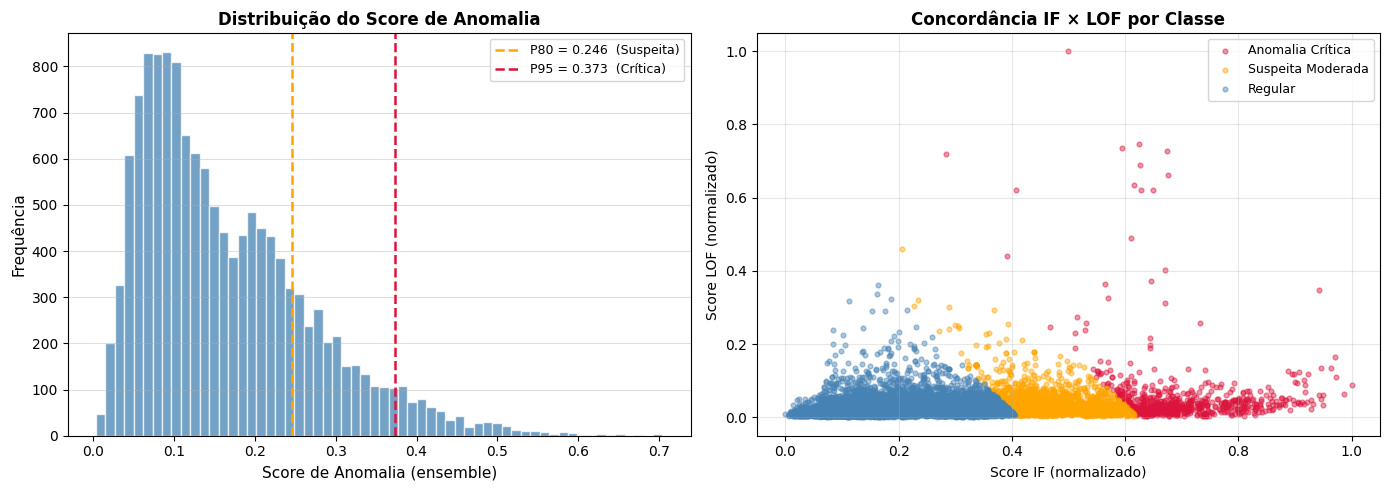

In [167]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.hist(score_ensemble, bins=60, color='steelblue', alpha=0.75, edgecolor='white')
ax1.axvline(P80, color='orange', linestyle='--', lw=1.8,
            label=f'P80 = {P80:.3f}  (Suspeita)')
ax1.axvline(P95, color='crimson', linestyle='--', lw=1.8,
            label=f'P95 = {P95:.3f}  (Crítica)')
ax1.set_xlabel('Score de Anomalia (ensemble)', fontsize=11)
ax1.set_ylabel('Frequência', fontsize=11)
ax1.set_title('Distribuição do Score de Anomalia', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.4)

ax2 = axes[1]
cores = {'Anomalia Crítica': 'crimson', 'Suspeita Moderada': 'orange', 'Regular': 'steelblue'}
for cls, cor in cores.items():
    mask_c = clean_df['classificacao'] == cls
    ax2.scatter(if_norm[mask_c], lof_norm[mask_c],
                c=cor, alpha=0.45, s=12, label=cls, rasterized=True)
ax2.set_xlabel('Score IF (normalizado)')
ax2.set_ylabel('Score LOF (normalizado)')
ax2.set_title('Concordância IF × LOF por Classe', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_01_score_distribuicao.png', dpi=150, bbox_inches='tight')
plt.show()


### 11.2 — Top Anomalias para Revisão Manual

Para cada anomalia identificamos o **driver principal**: a feature com maior desvio em relação à mediana dos registros regulares. Isso resume, em uma frase, o motivo mais provável da suspeição.

**Por que o score e o driver podem ter ordens diferentes?**

O `score_anomalia` mede **raridade multi-dimensional**: quão isolado o registro está no espaço de todas as 14 features juntas. Um registro pode ter sobrepreço moderado E gasto per capita alto E prazo atípico simultaneamente — essa combinação rara no espaço multi-dimensional dá um score alto.

O `driver_principal` aponta apenas a feature **mais extrema individualmente**. Um registro com sobrepreço de 900% (proporcao=10×) pode ter score menor do que um com sobrepreço de 284%, se no segundo caso o órgão também tem gasto per capita atípico, volume de licitações incomum e prazo fora do padrão — o conjunto é mais revelador que qualquer feature isolada.


In [168]:
# ─────────────────────────────────────────────────────────────────────────────
# IDENTIFICAÇÃO DO DRIVER PRINCIPAL
# Para cada anomalia: qual feature está mais distante da mediana dos regulares?
# z-score robusto = (valor_anomalia − mediana_Regular) / IQR_Regular
# ─────────────────────────────────────────────────────────────────────────────
mask_regular   = clean_df['classificacao'] == 'Regular'
feat_regular   = feat[mask_regular]
med_ref        = feat_regular.median()
iqr_ref        = (feat_regular.quantile(0.75) - feat_regular.quantile(0.25)).replace(0, 1)

anomalias_df   = clean_df[clean_df['flag_anomalia']].copy()
feat_anomalias = feat.loc[anomalias_df.index]
z_scores       = (feat_anomalias - med_ref) / iqr_ref

# Features que representam ausência de dados não devem ser drivers
FEATURES_EXCLUIR_DRIVER = {'tem_dados_financeiros', 'tem_populacao',
                            'categoria_cod', 'modalidade_grupo', 'mes_abertura'}
z_para_driver = z_scores.drop(columns=[c for c in FEATURES_EXCLUIR_DRIVER
                                        if c in z_scores.columns])

anomalias_df['driver_principal'] = z_para_driver.abs().idxmax(axis=1)
# z_score_driver: limita em 20 para exibição — acima disso é apenas "muito extremo"
# (valores como 500 são artefatos do clip de sobrepreco_pct / IQR_regular ≈ 1)
anomalias_df['z_score_driver'] = z_para_driver.abs().max(axis=1).clip(upper=20).round(2)

LABELS_DRIVER = {
    'sobrepreco_pct':              'Sobrepreço',
    'proporcao_hom_est':           'Relação Valor Anômala',
    'valor_estimado_log1p':        'Valor Estimado Atípico',
    'lead_time_log1p':             'Prazo Processual Atípico',
    'desconto_pct':                'Desconto Atípico',
    'orgao_freq_pct':              'Padrão de Órgão Atípico',
    'volume_orgao_ano_log1p':      'Volume Anual Atípico',
    'gasto_per_capita_log1p':      'Gasto per Capita Atípico',
    'desvio_per_capita_categoria': 'Gasto Desproporcional ao Porte',
}
anomalias_df['tipo_anomalia'] = (
    anomalias_df['driver_principal'].map(LABELS_DRIVER).fillna('Outro')
)

# ─────────────────────────────────────────────────────────────────────────────
# CONTEXTO LEGÍVEL DO DRIVER
# Traduz o driver técnico em uma frase com valores reais do registro
# ─────────────────────────────────────────────────────────────────────────────
# Constrói driver_contexto de forma vetorizada (sem apply — evita problemas com NaN)
# Para cada driver possível, gera o texto de contexto usando colunas do DataFrame
prop_s = anomalias_df['proporcao_homologado_estimado'].fillna(0)
lead_s = anomalias_df['lead_time_dias'].fillna(0)
val_s  = anomalias_df['valor_estimado'].fillna(0)
drv    = anomalias_df['driver_principal'].fillna('')

ctx = pd.Series('desvio multi-dimensional', index=anomalias_df.index)

ctx = ctx.where(drv != 'sobrepreco_pct',
    'pago ' + prop_s.map(lambda x: f'{x:.1f}') + '× o estimado')
ctx = ctx.where((drv != 'sobrepreco_pct') | (prop_s > 0), 'sobrepreço s/ dados')

ctx = ctx.where(drv != 'proporcao_hom_est',
    'proporção ' + prop_s.map(lambda x: f'{x:.1f}') + '×')
ctx = ctx.where((drv != 'proporcao_hom_est') | (prop_s > 0), 'relação anômala')

ctx = ctx.where(drv != 'lead_time_log1p',
    lead_s.map(lambda x: f'{int(x)} dias de prazo' if x > 0 else 'prazo atípico'))

ctx = ctx.where(drv != 'valor_estimado_log1p',
    val_s.map(lambda x: f'R$ {x:,.0f} estimado' if x > 0 else 'valor atípico'))

ctx = ctx.where(drv != 'gasto_per_capita_log1p',   'gasto per capita muito alto')
ctx = ctx.where(drv != 'desvio_per_capita_categoria', 'desproporcional vs pares')
ctx = ctx.where(drv != 'orgao_freq_pct',            'padrão de órgão atípico')
ctx = ctx.where(drv != 'volume_orgao_ano_log1p',    'volume de licitações atípico')
ctx = ctx.where(drv != 'desconto_pct',
    prop_s.map(lambda x: f'desconto de {(1-x)*100:.0f}%' if 0 < x < 1 else 'desconto atípico'))

anomalias_df['driver_contexto'] = ctx

# ─────────────────────────────────────────────────────────────────────────────
# FORMATOS LEGÍVEIS PARA REVISÃO
# ─────────────────────────────────────────────────────────────────────────────
anomalias_df['valor_estimado_fmt'] = anomalias_df['valor_estimado'].apply(
    lambda x: f'R$ {x:,.0f}' if pd.notna(x) and x > 0 else '—'
)
anomalias_df['valor_homol_fmt'] = anomalias_df['valor_ou_desconto_homologado'].apply(
    lambda x: f'R$ {x:,.0f}' if pd.notna(x) and x > 0 else '—'
)
anomalias_df['proporcao_fmt'] = anomalias_df['proporcao_homologado_estimado'].apply(
    lambda x: f'{x:.2f}×' if pd.notna(x) and x > 0 else '—'
)
anomalias_df['lead_time_fmt'] = anomalias_df['lead_time_dias'].apply(
    lambda x: f'{int(x)} dias' if pd.notna(x) and x > 0 else '—'
)

# ─────────────────────────────────────────────────────────────────────────────
# DISPLAY: colunas para revisão manual
# score_anomalia  = raridade multi-dimensional (ensemble IF+LOF)
# tipo_anomalia   = motivo principal legível
# driver_contexto = contexto específico do registro com valor real
# ─────────────────────────────────────────────────────────────────────────────
cols = [
    'orgao', 'municipio_extraido', 'categoria_objeto',
    'valor_estimado_fmt', 'valor_homol_fmt', 'proporcao_fmt', 'lead_time_fmt',
    'score_anomalia', 'tipo_anomalia', 'driver_contexto',
]
cols = [c for c in cols if c in anomalias_df.columns]

criticas  = anomalias_df[anomalias_df['classificacao'] == 'Anomalia Crítica']
suspeitas = anomalias_df[anomalias_df['classificacao'] == 'Suspeita Moderada']

print('=' * 70)
print('  TOP 20 — ANOMALIAS CRÍTICAS (score ≥ P95)')
print('  score_anomalia: raridade no espaço de 14 features (ensemble IF+LOF)')
print('  driver_contexto: motivo principal com valor real do registro')
print('=' * 70)
display(criticas.sort_values('score_anomalia', ascending=False).head(20)[cols])

print()
print('Distribuição por tipo de anomalia (Críticas):')
print(criticas['tipo_anomalia'].value_counts().to_string())

print()
print('─' * 70)
print('  TOP 10 — SUSPEITAS MODERADAS (P80 ≤ score < P95)')
print('─' * 70)
display(suspeitas.sort_values('score_anomalia', ascending=False).head(10)[cols])


  TOP 20 — ANOMALIAS CRÍTICAS (score ≥ P95)
  score_anomalia: raridade no espaço de 14 features (ensemble IF+LOF)
  driver_contexto: motivo principal com valor real do registro


,orgao,municipio_extraido,categoria_objeto,valor_estimado_fmt,valor_homol_fmt,proporcao_fmt,lead_time_fmt,score_anomalia,tipo_anomalia,driver_contexto
4687,APPA-Administração dos Portos de Paranaguá e Antonina,Paranaguá,obras,"R$ 914,942,160","R$ 3,515,226,100",3.84×,61 dias,0.70,Sobrepreço,pago 3.8× o estimado
205,UENP-Universidade Estadual do Norte do Paraná,None,mobiliario,R$ 500,—,—,—,0.70,Valor Estimado Atípico,R$ 500 estimado
7115,UEM-Universidade Estadual de Maringá,Maringá,outros,"R$ 15,000",—,—,—,0.70,Valor Estimado Atípico,"R$ 15,000 estimado"
7137,UEM-Universidade Estadual de Maringá,Maringá,outros,"R$ 15,000",—,—,—,0.67,Valor Estimado Atípico,"R$ 15,000 estimado"
4544,UNIOESTE MCROND-Universidade Estadual do Oeste do Paraná - Campus Marechal Cândido Rondon,Marechal Cândido Rondon,outros,"R$ 103,333",—,—,—,0.67,Valor Estimado Atípico,"R$ 103,333 estimado"
7123,UEM-Universidade Estadual de Maringá,Maringá,outros,"R$ 63,994",—,—,—,0.65,Valor Estimado Atípico,"R$ 63,994 estimado"
7166,UEM-Universidade Estadual de Maringá,Maringá,outros,"R$ 26,667",—,—,—,0.65,Valor Estimado Atípico,"R$ 26,667 estimado"
116,UEL-Universidade Estadual de Londrina,Londrina,veiculos,"R$ 3,224,425,182",—,—,—,0.65,Gasto Desproporcional ao Porte,desproporcional vs pares
7319,IDR-Instituto de Desenvolvimento Rural do Paraná - IAPAR-EMATER,None,outros,"R$ 45,150","R$ 5,651,100",10.00×,3 dias,0.64,Sobrepreço,pago 10.0× o estimado
4683,APPA-Administração dos Portos de Paranaguá e Antonina,Paranaguá,servicos,"R$ 28,516,784,193",R$ 1,0.00×,40 dias,0.64,Gasto per Capita Atípico,gasto per capita muito alto



Distribuição por tipo de anomalia (Críticas):
tipo_anomalia
Gasto per Capita Atípico          287
Valor Estimado Atípico            177
Gasto Desproporcional ao Porte    132
Sobrepreço                         29
Volume Anual Atípico               27
Desconto Atípico                   22
Prazo Processual Atípico            3

──────────────────────────────────────────────────────────────────────
  TOP 10 — SUSPEITAS MODERADAS (P80 ≤ score < P95)
──────────────────────────────────────────────────────────────────────


,orgao,municipio_extraido,categoria_objeto,valor_estimado_fmt,valor_homol_fmt,proporcao_fmt,lead_time_fmt,score_anomalia,tipo_anomalia,driver_contexto
5571,UEL-Universidade Estadual de Londrina,Londrina,saude,—,—,—,—,0.37,Valor Estimado Atípico,valor atípico
1084,UNIOESTE FBELT-Universidade Estadual do Oeste do Paraná - Campus Francisco Beltrão,Francisco Beltrão,limpeza,"R$ 5,320,000","R$ 2,791,596",0.52×,12 dias,0.37,Gasto per Capita Atípico,gasto per capita muito alto
10103,APPA-Administração dos Portos de Paranaguá e Antonina,Paranaguá,obras,—,—,—,—,0.37,Valor Estimado Atípico,valor atípico
344,UNIOESTE CASC-Universidade Estadual do Oeste do Paraná - Campus Cascavel,Cascavel,saude,"R$ 31,525,703","R$ 16,586,187",0.53×,54 dias,0.37,Gasto per Capita Atípico,gasto per capita muito alto
12156,CCTG-Centro Cultural Teatro Guaira,Guaíra,outros,"R$ 2,743,640",—,—,—,0.37,Gasto per Capita Atípico,gasto per capita muito alto
7097,SEFA-Secretaria de Estado da Fazenda,None,servicos,"R$ 496,453,750","R$ 228,581,500",0.46×,243 dias,0.37,Volume Anual Atípico,volume de licitações atípico
1901,UNIOESTE CASC-Universidade Estadual do Oeste do Paraná - Campus Cascavel,Cascavel,obras,"R$ 13,835,935",—,—,—,0.37,Gasto per Capita Atípico,gasto per capita muito alto
296,FERROESTE-Estrada de Ferro Paraná Oeste S.A.,None,veiculos,—,—,—,—,0.37,Valor Estimado Atípico,valor atípico
5351,UEL-Universidade Estadual de Londrina,Londrina,saude,"R$ 198,668,350","R$ 186,958,750",0.94×,96 dias,0.37,Gasto per Capita Atípico,gasto per capita muito alto
1734,SESP-Secretaria de Estado da Segurança Pública,None,veiculos,"R$ 400,000",—,—,—,0.37,Prazo Processual Atípico,prazo atípico


---
## 12 — Exportação dos Resultados

Dois arquivos CSV são gerados na pasta `exports/`:

| Arquivo | Conteúdo |
|---|---|
| `licitacoes_com_score_ml.csv` | Todos os ~13.500 registros com score e classificação |
| `licitacoes_anomalias_ml.csv` | Apenas anomalias (Críticas + Suspeitas) com driver e contexto |

**Colunas principais para análise:**

- `score_anomalia` — score ensemble [0,1]; quanto maior, mais anômalo no espaço multi-dimensional
- `classificacao` — Anomalia Crítica / Suspeita Moderada / Regular
- `tipo_anomalia` — motivo legível (ex: "Sobrepreço", "Gasto per Capita Atípico")
- `driver_contexto` — contexto específico com valores reais (ex: "pago 3.8× o estimado")
- `driver_principal` — nome técnico da feature mais extrema (para análise avançada)


In [169]:
# Exporta todos os registros com score (ordenados do mais anômalo para o regular)
export_df = clean_df.sort_values('score_anomalia', ascending=False).copy()

path_completo  = EXPORTS_DIR / 'licitacoes_com_score_ml.csv'
path_anomalias = EXPORTS_DIR / 'licitacoes_anomalias_ml.csv'

export_df.to_csv(path_completo, sep=';', index=False)
anomalias_df.sort_values('score_anomalia', ascending=False).to_csv(
    path_anomalias, sep=';', index=False
)

n_criticas  = (anomalias_df['classificacao'] == 'Anomalia Crítica').sum()
n_suspeitas = (anomalias_df['classificacao'] == 'Suspeita Moderada').sum()

print('=' * 60)
print('  EXPORTAÇÃO CONCLUÍDA')
print('=' * 60)
print(f'  {path_completo.name}')
print(f'    → {len(export_df):,} registros (dataset completo com scores)')
print()
print(f'  {path_anomalias.name}')
print(f'    → {len(anomalias_df):,} anomalias no total')
print(f'       Críticas  (≥ P95): {n_criticas:,}')
print(f'       Suspeitas (≥ P80): {n_suspeitas:,}')
print()
print('  Colunas-chave exportadas:')
print('    score_anomalia, classificacao, tipo_anomalia,')
print('    tipo_anomalia, driver_contexto, driver_principal,')
print('    proporcao_homologado_estimado, lead_time_dias')
print()
print(f'  Arquivos salvos em: {EXPORTS_DIR.resolve()}')


  EXPORTAÇÃO CONCLUÍDA
  licitacoes_com_score_ml.csv
    → 13,536 registros (dataset completo com scores)

  licitacoes_anomalias_ml.csv
    → 2,708 anomalias no total
       Críticas  (≥ P95): 677
       Suspeitas (≥ P80): 2,031

  Colunas-chave exportadas:
    score_anomalia, classificacao, tipo_anomalia,
    tipo_anomalia, driver_contexto, driver_principal,
    proporcao_homologado_estimado, lead_time_dias

  Arquivos salvos em: /Users/azevedo/GitHub/anomalyClassifier/exports


---
## 13 — Sumário Final e Limitações

Apresenta o resumo completo do pipeline executado: volume de dados processados, quantidade de anomalias detectadas em cada nível de criticidade, a metodologia utilizada e as limitações que devem ser declaradas no TCC.

A limitação mais importante é a ausência de rótulos confirmados de fraude: os resultados indicam **desvio estatístico do padrão**, não fraude. Cada anomalia crítica identificada é um **ponto de partida para investigação**, não uma conclusão.


In [170]:
n_criticas  = (clean_df['classificacao'] == 'Anomalia Crítica').sum()
n_suspeitas = (clean_df['classificacao'] == 'Suspeita Moderada').sum()
n_regular   = (clean_df['classificacao'] == 'Regular').sum()
n_total     = len(clean_df)
ano_min     = clean_df['ano_abertura'][clean_df['ano_abertura'] > 0].min()
ano_max     = clean_df['ano_abertura'].max()

print('=' * 72)
print('  SUMÁRIO — DETECÇÃO DE ANOMALIAS EM LICITAÇÕES PÚBLICAS DO PARANÁ')
print('=' * 72)
print(f'  Período analisado              : {ano_min} – {ano_max}')
print(f'  Total de registros             : {n_total:,}')
print(f'  Municípios identificados       : {clean_df["municipio_extraido"].notna().sum():,}')
print(f'  Com dados IDHM/população       : {clean_df["populacao"].notna().sum():,}')
print()
print(f'  Anomalias Críticas   (≥ P95)   : {n_criticas:,}  ({n_criticas/n_total*100:.1f}%)')
print(f'  Suspeitas Moderadas  (≥ P80)   : {n_suspeitas:,}  ({n_suspeitas/n_total*100:.1f}%)')
print(f'  Regulares            (< P80)   : {n_regular:,}  ({n_regular/n_total*100:.1f}%)')
print()
print('  METODOLOGIA')
print(f'    Algoritmos  : Isolation Forest + LOF (ensemble {PESO_IF:.0%}/{PESO_LOF:.0%})')
print(f'    Features    : {len(NOMES_FEATURES)} variáveis (financeiras, temporais, IDHM, per capita)')
print(f'    Thresholds  : P95 = {P95:.4f} (Crítica)  |  P80 = {P80:.4f} (Suspeita)')
print()
print('  LIMITAÇÕES')
print('  1. SEM RÓTULOS: resultados indicam desvio estatístico, não fraude confirmada.')
print('     Registros anômalos requerem revisão manual.')
print('  2. IDHM 2010: último censo disponível — mudanças desde 2010 não refletidas.')
print('  3. MUNICÍPIO: órgãos estaduais sem município no nome não têm gasto per capita.')
print('     Contribuem com features não-contextuais (valor, lead time, modalidade).')
print('=' * 72)


  SUMÁRIO — DETECÇÃO DE ANOMALIAS EM LICITAÇÕES PÚBLICAS DO PARANÁ
  Período analisado              : 2018 – 2099
  Total de registros             : 13,536
  Municípios identificados       : 2,457
  Com dados IDHM/população       : 2,457

  Anomalias Críticas   (≥ P95)   : 677  (5.0%)
  Suspeitas Moderadas  (≥ P80)   : 2,031  (15.0%)
  Regulares            (< P80)   : 10,828  (80.0%)

  METODOLOGIA
    Algoritmos  : Isolation Forest + LOF (ensemble 60%/40%)
    Features    : 14 variáveis (financeiras, temporais, IDHM, per capita)
    Thresholds  : P95 = 0.3733 (Crítica)  |  P80 = 0.2463 (Suspeita)

  LIMITAÇÕES
  1. SEM RÓTULOS: resultados indicam desvio estatístico, não fraude confirmada.
     Registros anômalos requerem revisão manual.
  2. IDHM 2010: último censo disponível — mudanças desde 2010 não refletidas.
  3. MUNICÍPIO: órgãos estaduais sem município no nome não têm gasto per capita.
     Contribuem com features não-contextuais (valor, lead time, modalidade).
